#Task 2: Sentiment Analysis using NLP Pipeline & ML Model

In [42]:
# Importing required libraries

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [43]:
# Downloading required NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [44]:
# Uploading dataset file in Colab

from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (4).zip


In [45]:
# Extracting uploaded zip file

import zipfile
import os

zip_path = "archive.zip"   # your uploaded file name
extract_path = "sentiment140_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")
print(os.listdir(extract_path))

Files extracted successfully!
['training.1600000.processed.noemoticon.csv']


In [46]:
# Checking extracted files

import os

for root, dirs, files in os.walk("sentiment140_data"):
    for file in files:
        print(os.path.join(root, file))

sentiment140_data/training.1600000.processed.noemoticon.csv


In [47]:
# Loading Sentiment140 dataset correctly

import pandas as pd

df = pd.read_csv(
    "sentiment140_data/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None
)

df.columns = ["target", "ids", "date", "flag", "user", "text"]

df.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [48]:
# Keeping only required columns

df = df[["text", "target"]]
df.head()

,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [49]:
# Converting labels into readable format

df["sentiment"] = df["target"].map({0: "negative", 4: "positive"})
df = df[["text", "sentiment"]]

df.head()

,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",negative
1,is upset that he can't update his Facebook by ...,negative
2,@Kenichan I dived many times for the ball. Man...,negative
3,my whole body feels itchy and like its on fire,negative
4,"@nationwideclass no, it's not behaving at all....",negative


In [50]:
# Taking smaller sample for faster running

df = df.sample(20000, random_state=42)
df = df.reset_index(drop=True)

print(df.shape)
df.head()

(20000, 2)


,text,sentiment
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,negative
1,"@misstoriblack cool , i have no tweet apps fo...",negative
2,@TiannaChaos i know just family drama. its la...,negative
3,School email won't open and I have geography ...,negative
4,upper airways problem,negative


In [51]:
# Basic dataset information

print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Shape of dataset: (20000, 2)

Columns: ['text', 'sentiment']

Missing values:
 text         0
sentiment    0
dtype: int64


In [52]:
# Checking class distribution

print(df["sentiment"].value_counts())

sentiment
positive    10058
negative     9942
Name: count, dtype: int64


In [53]:
# Viewing sample texts

df.head(10)

,text,sentiment
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,negative
1,"@misstoriblack cool , i have no tweet apps fo...",negative
2,@TiannaChaos i know just family drama. its la...,negative
3,School email won't open and I have geography ...,negative
4,upper airways problem,negative
5,Going to miss Pastor's sermon on Faith...,negative
6,on lunch....dj should come eat with me,positive
7,@piginthepoke oh why are you feeling like that?,negative
8,gahh noo!peyton needs to live!this is horrible,negative
9,@mrstessyman thank you glad you like it! There...,positive


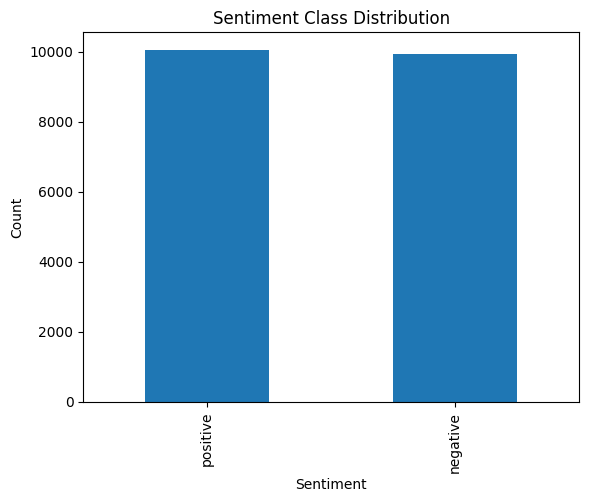

In [54]:
# Plotting class distribution

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [55]:
# Initializing NLP tools

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [56]:
# Text preprocessing function

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join back into cleaned sentence
    cleaned_text = " ".join(tokens)

    return cleaned_text

In [57]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [58]:
# Applying preprocessing to all text

df["clean_text"] = df["text"].apply(preprocess_text)

df[["text", "clean_text", "sentiment"]].head()

,text,clean_text,sentiment
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok,negative
1,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr,negative
2,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time u hang kim...,negative
3,School email won't open and I have geography ...,school email wont open geography stuff revise ...,negative
4,upper airways problem,upper airway problem,negative


In [59]:
# Checking empty cleaned texts

print("Empty cleaned texts:", (df["clean_text"].str.strip() == "").sum())

Empty cleaned texts: 108


In [60]:
# Encoding labels for machine learning

label_mapping = {"negative": 0, "positive": 1}
df["label"] = df["sentiment"].map(label_mapping)

df[["sentiment", "label"]].head()

,sentiment,label
0,negative,0
1,negative,0
2,negative,0
3,negative,0
4,negative,0


In [61]:
# Splitting into train and test sets

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


In [62]:
# Bag of Words vectorization

bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW train shape:", X_train_bow.shape)
print("BoW test shape:", X_test_bow.shape)

BoW train shape: (16000, 5000)
BoW test shape: (4000, 5000)


In [63]:
# TF-IDF vectorization

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (16000, 5000)
TF-IDF test shape: (4000, 5000)


In [64]:
# Function to evaluate model performance

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [65]:
# Logistic Regression using Bag of Words

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_bow)

print("Logistic Regression (BoW)")
print(classification_report(y_test, y_pred_lr_bow))

Logistic Regression (BoW)
              precision    recall  f1-score   support

           0       0.75      0.71      0.73      1988
           1       0.73      0.76      0.74      2012

    accuracy                           0.74      4000
   macro avg       0.74      0.74      0.74      4000
weighted avg       0.74      0.74      0.74      4000



In [66]:
# Naive Bayes using Bag of Words

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

print("Naive Bayes (BoW)")
print(classification_report(y_test, y_pred_nb_bow))

Naive Bayes (BoW)
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1988
           1       0.73      0.73      0.73      2012

    accuracy                           0.73      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.73      0.73      0.73      4000



In [67]:
# Decision Tree using Bag of Words

dt_bow = DecisionTreeClassifier(random_state=42)
dt_bow.fit(X_train_bow, y_train)
y_pred_dt_bow = dt_bow.predict(X_test_bow)

print("Decision Tree (BoW)")
print(classification_report(y_test, y_pred_dt_bow))

Decision Tree (BoW)
              precision    recall  f1-score   support

           0       0.67      0.69      0.68      1988
           1       0.68      0.67      0.67      2012

    accuracy                           0.68      4000
   macro avg       0.68      0.68      0.68      4000
weighted avg       0.68      0.68      0.68      4000



In [68]:
# Logistic Regression using TF-IDF

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("Logistic Regression (TF-IDF)")
print(classification_report(y_test, y_pred_lr_tfidf))

Logistic Regression (TF-IDF)
              precision    recall  f1-score   support

           0       0.75      0.72      0.74      1988
           1       0.73      0.76      0.75      2012

    accuracy                           0.74      4000
   macro avg       0.74      0.74      0.74      4000
weighted avg       0.74      0.74      0.74      4000



In [69]:
# Naive Bayes using TF-IDF

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("Naive Bayes (TF-IDF)")
print(classification_report(y_test, y_pred_nb_tfidf))

Naive Bayes (TF-IDF)
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1988
           1       0.73      0.73      0.73      2012

    accuracy                           0.73      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.73      0.73      0.73      4000



In [70]:
# Decision Tree using TF-IDF

dt_tfidf = DecisionTreeClassifier(random_state=42)
dt_tfidf.fit(X_train_tfidf, y_train)
y_pred_dt_tfidf = dt_tfidf.predict(X_test_tfidf)

print("Decision Tree (TF-IDF)")
print(classification_report(y_test, y_pred_dt_tfidf))

Decision Tree (TF-IDF)
              precision    recall  f1-score   support

           0       0.67      0.67      0.67      1988
           1       0.67      0.68      0.68      2012

    accuracy                           0.67      4000
   macro avg       0.67      0.67      0.67      4000
weighted avg       0.67      0.67      0.67      4000



In [71]:
# Comparing all model performances

results = []

results.append(evaluate_model("Logistic Regression (BoW)", y_test, y_pred_lr_bow))
results.append(evaluate_model("Naive Bayes (BoW)", y_test, y_pred_nb_bow))
results.append(evaluate_model("Decision Tree (BoW)", y_test, y_pred_dt_bow))

results.append(evaluate_model("Logistic Regression (TF-IDF)", y_test, y_pred_lr_tfidf))
results.append(evaluate_model("Naive Bayes (TF-IDF)", y_test, y_pred_nb_tfidf))
results.append(evaluate_model("Decision Tree (TF-IDF)", y_test, y_pred_dt_tfidf))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (BoW),0.73650,0.736889,0.73650,0.736338
1,Naive Bayes (BoW),0.73000,0.730018,0.73000,0.730002
2,Decision Tree (BoW),0.67750,0.677706,0.67750,0.677460
3,Logistic Regression (TF-IDF),0.74225,0.742623,0.74225,0.742101
4,Naive Bayes (TF-IDF),0.72925,0.729270,0.72925,0.729252
5,Decision Tree (TF-IDF),0.67475,0.674749,0.67475,0.674731


In [72]:
# Finding best model

best_model = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression (TF-IDF)
Accuracy                          0.74225
Precision                        0.742623
Recall                            0.74225
F1 Score                         0.742101
Name: 3, dtype: object


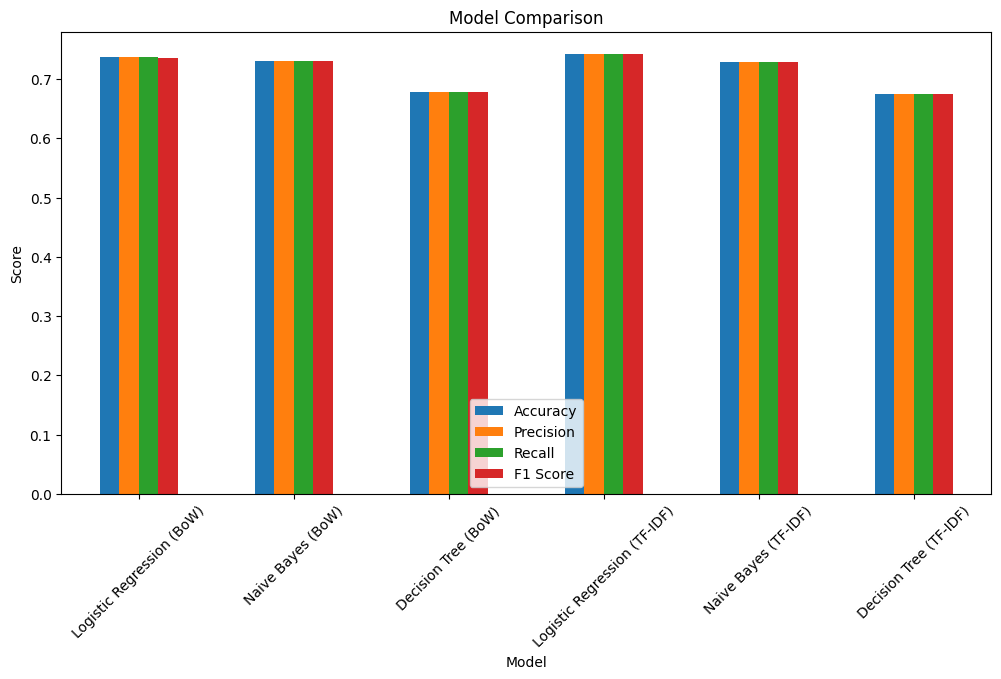

In [73]:
# Plotting model comparison

results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [74]:
# Testing custom sentences using best model

sample_reviews = [
    "I really loved this product, it was amazing!",
    "Worst experience ever, I hate it.",
    "This is okay, not too bad."
]

sample_clean = [preprocess_text(text) for text in sample_reviews]
sample_vector = tfidf_vectorizer.transform(sample_clean)

predictions = lr_tfidf.predict(sample_vector)

reverse_label_mapping = {0: "negative", 1: "positive"}

for review, pred in zip(sample_reviews, predictions):
    print("Review:", review)
    print("Predicted Sentiment:", reverse_label_mapping[pred])
    print("-" * 60)

Review: I really loved this product, it was amazing!
Predicted Sentiment: positive
------------------------------------------------------------
Review: Worst experience ever, I hate it.
Predicted Sentiment: negative
------------------------------------------------------------
Review: This is okay, not too bad.
Predicted Sentiment: negative
------------------------------------------------------------
